# ipynb/multirm_cls_compare_nofont2.ipynb - MultiRM 分类对比2(无字体) / MultiRM classification compare 2 (no font)

## 项目背景 / Background
MultiRM 分类对比2(无字体)
MultiRM classification compare 2 (no font)

## 功能模块 / Modules
- MultiRM 分类结果对比(变体)
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: ipynb/multirm_cls_compare_nofont.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



New names:
• `` -> `...1`


[1] "数据预览:"
# A tibble: 52 × 4
   Model  Site   AUCb  Rank
   <fct>  <fct> <dbl> <int>
 1 mRModN Am    0.964     2
 2 mRModN Cm    0.956     1
 3 mRModN Gm    0.99      1
 4 mRModN Tm    0.945     2
 5 mRModN m1A   0.914     1
 6 mRModN m5C   0.986     1
 7 mRModN m5U   0.956     1
 8 mRModN m6A   0.987     1
 9 mRModN m6Am  0.991     1
10 mRModN m7G   0.979     2
# ℹ 42 more rows

=== 各修饰位点最佳模型 ===
# A tibble: 13 × 3
# Groups:   Site [13]
   Site     Model   AUCb
   <fct>    <fct>  <dbl>
 1 Am       ModX   0.999
 2 Cm       mRModN 0.956
 3 Gm       mRModN 0.99 
 4 Tm       ModX   0.982
 5 m1A      mRModN 0.914
 6 m5C      mRModN 0.986
 7 m5U      mRModN 0.956
 8 m6A      mRModN 0.987
 9 m6Am     mRModN 0.991
10 m7G      ModX   0.989
11 hPsi     mRModN 0.945
12 Atol     mRModN 0.990
13 Avg AUCb mRModN 0.967

=== 各模型胜出位点数 ===
# A tibble: 13 × 3
# Groups:   Site [13]
   Site     Model   Wins
   <fct>    <fct>  <int>
 1 Am       ModX       1
 2 Cm       mRModN     1
 3 Gm       mRModN    

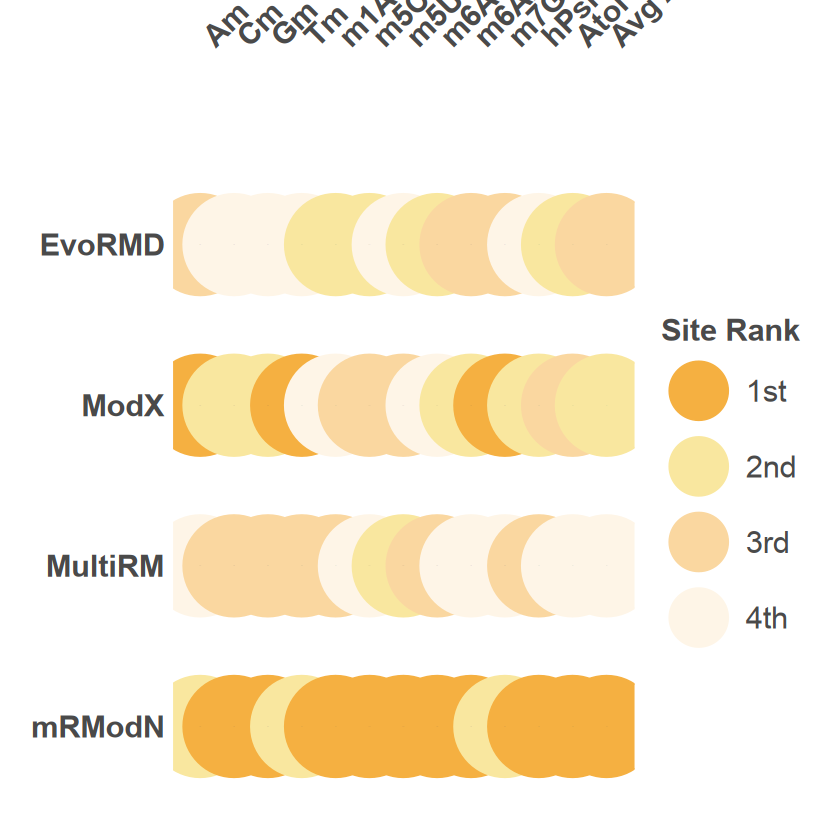

In [3]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(readxl)
library(scales)

font_size <- 18

# --- 数据读取与处理 ---
data_file <- "multirm_loc_comp/multirm_aucb_comp2.xlsx"
df_raw <- read_excel(data_file, sheet = 1)

# 取前4行有效数据
df_data <- df_raw[1:4, ]

# 从第一列提取模型名称
model_names <- as.character(df_data[[1]])
df_data <- df_data[, -1]
df_data$Model <- model_names

# 转换为长格式数据
site_cols <- c("Am", "Cm", "Gm", "Tm", "m1A", "m5C", "m5U", "m6A", "m6Am", "m7G", "hPsi", "Atol")
plot_data <- df_data %>%
  pivot_longer(cols = c(all_of(site_cols), "Avg AUCb"), names_to = "Site", values_to = "AUCb") %>%
  mutate(
    Site = factor(Site, levels = c(site_cols, "Avg AUCb")),
    Model = factor(Model, levels = model_names)
  )

# --- 在每个位点内部计算排名 ---
plot_data <- plot_data %>%
  group_by(Site) %>%
  mutate(Rank = rank(-AUCb, ties.method = "first")) %>%
  ungroup()

print("数据预览:")
print(plot_data)

# --- 定义颜色深度（按排名）---
rank_palette <- c(
  "1" = "#F5B041",  # 明亮的金色 (最佳)
  "2" = "#F9E79F",  # 浅黄色
  "3" = "#FAD7A0",  # 中等浅橙色
  "4" = "#FEF5E7"   # 极浅橙色
)

# --- 绘图 ---
p1 <- ggplot() +
  geom_point(data = plot_data, aes(x = Site, y = Model, color = as.factor(Rank)), size = 28) +
  geom_text(data = plot_data, aes(x = Site, y = Model, label = floor(AUCb * 100) / 100),
            size = 0, fontface = "bold", color = "#4A4B4B") +
  scale_color_manual(name = "Site Rank", values = rank_palette,
                     labels = c("1st", "2nd", "3rd", "4th")) +
  scale_x_discrete(position = "top", expand = expansion(add = c(0.8, 0.8))) +
  scale_y_discrete(expand = expansion(add = c(0.5, 0.5))) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(size = font_size, face = "bold", color = "#4A4A4A", angle = 45, hjust = 0),
    axis.text.y = element_text(size = font_size, face = "bold", color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_rect(fill = "white", color = NA),
    plot.background = element_rect(fill = "white", color = NA),
    legend.position = "right",
    legend.title = element_text(size = font_size, face = "bold", color = "#4A4A4A"),
    legend.text = element_text(size = font_size, color = "#4A4A4A"),
    plot.margin = margin(20, 20, 20, 20)
  ) +
  guides(
    color = guide_legend(
      override.aes = list(size = 16),
      order = 1
    )
  )

# --- 保存图片 ---
dir.create("png3", showWarnings = FALSE)
ggsave("png3/multirm_aucb_compare2.pdf", p1, width = 16, height = 6, dpi = 300)
print(p1)

# --- 额外统计信息 ---
cat("\n=== 各修饰位点最佳模型 ===\n")
best_per_site <- plot_data %>%
  group_by(Site) %>%
  slice_max(AUCb, n = 1) %>%
  select(Site, Model, AUCb)
print(best_per_site)

cat("\n=== 各模型胜出位点数 ===\n")
best_per_site %>%
  count(Model, name = "Wins") %>%
  print()
